# Import Libraries

In [1]:
import os, random, numpy as np, torch, mne
from scipy.signal import butter, filtfilt
from collections import Counter
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# Experiment Configuration and Parameters

In [4]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
SFREQ = 256
EPOCH_SEC = 30
EPOCH_SAMPLES = SFREQ * EPOCH_SEC  
EOG_CHANNEL = "EOG-R"
NUM_CLASSES = 5
LABEL_MAP = {"Wake":0, "Stage 1 sleep":1, "Stage 2 sleep":2, "Stage 3 sleep":3, "REM sleep":4}
STAGE_NAMES = ["Wake(W)", "N1", "N2", "N3", "REM"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 40
PATIENCE = 8

# PATHS

In [5]:
SIGNALS_PATH = r"C:\Users\waheed\Desktop\Sleep_Stages_Classification\Dataset\Signals"
ANNOT_PATH = r"C:\Users\waheed\Desktop\Sleep_Stages_Classification\Dataset\Annotations"

# BANDPASS FILTER

In [6]:
def bandpass_filter(data, lowcut=0.3, highcut=35.0, fs=SFREQ, order=5):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

# PARSE ANNOTATIONS

In [7]:
def parse_annotations(xml_path):
    tree = ET.parse(xml_path)
    stages = []
    for event in tree.getroot().iter('ScoredEvent'):
        concept = event.find('EventConcept')
        start = event.find('Start')
        duration = event.find('Duration')
        if concept is None or start is None or duration is None:
            continue
        text = concept.text.strip().split("|")[0]
        if text in LABEL_MAP:
            stages.append({"label": LABEL_MAP[text],
                           "start": float(start.text),
                           "duration": float(duration.text)})
    return stages


# Create Labels for 30-Second Epochs

In [8]:
def create_epoch_labels(stages, num_epochs):
    labels = np.full(num_epochs, -1, dtype=np.int64)
    for s in stages:
        start_ep = int(s["start"] // EPOCH_SEC)
        end_ep = int((s["start"] + s["duration"]) // EPOCH_SEC)
        for i in range(start_ep, min(end_ep, num_epochs)):
            labels[i] = s["label"]
    return labels

# Load and Preprocess Subject Data

In [9]:
def load_subject(subj_id):
    edf_file = os.path.join(SIGNALS_PATH, f"mesa-sleep-{subj_id}.edf")
    xml_file = os.path.join(ANNOT_PATH, f"mesa-sleep-{subj_id}-nsrr.xml")
    
    raw = mne.io.read_raw_edf(edf_file, include=[EOG_CHANNEL], preload=True, verbose=False)
    signal = raw.get_data()[0]
    
    signal = bandpass_filter(signal)
    
    signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-8)
    
    num_epochs = len(signal) // EPOCH_SAMPLES
    epochs = []
    for i in range(num_epochs):
        seg = signal[i*EPOCH_SAMPLES:(i+1)*EPOCH_SAMPLES]
        epochs.append(seg)
    epochs = np.array(epochs)
    
    stages = parse_annotations(xml_file)
    labels = create_epoch_labels(stages, num_epochs)
    
    mask = labels >= 0
    return epochs[mask], labels[mask]

# Load Dataset for All Subjects

In [10]:
def load_all_subjects():
    subject_ids = []
    for f in sorted(os.listdir(SIGNALS_PATH)):
        if f.endswith('.edf'):
            sid = f.replace("mesa-sleep-","").replace(".edf","")
            subject_ids.append(sid)
    
    all_data = {}
    for sid in subject_ids:
        print(f"Loading subject {sid}...", flush=True)
        X, y = load_subject(sid)
        all_data[sid] = (X, y)
        print(f"  -> {len(y)} epochs, distribution: {dict(Counter(y))}", flush=True)
    return all_data, subject_ids


# Merge Subject Data into a Unified Dataset

In [11]:
def merge_data(all_data, ids):
    X_list, y_list = [], []
    for sid in ids:
        X, y = all_data[sid]
        X_list.append(X)
        y_list.append(y)
    return np.concatenate(X_list), np.concatenate(y_list)


# Signal Augmentation for EOG Epochs

In [26]:
def augment_signal(x):
    aug = x.copy()
    choice = random.randint(0, 2)
    if choice == 0:  # Gaussian noise
        aug += np.random.normal(0, 0.05, aug.shape)
    elif choice == 1:  # Amplitude scaling
        scale = np.random.uniform(0.8, 1.2)
        aug *= scale
    else:  
        shift = np.random.randint(-200, 200)
        aug = np.roll(aug, shift)
    return aug


# Data Balancing with Signal Augmentation

In [27]:
def augment_minority(X, y, target_count=None):
    counts = Counter(y)
    if target_count is None:
        target_count = max(counts.values())
    
    X_aug, y_aug = list(X), list(y)
    for cls in range(NUM_CLASSES):
        if counts.get(cls, 0) < target_count:
            cls_indices = np.where(y == cls)[0]
            if len(cls_indices) == 0:
                continue
            needed = target_count - counts[cls]
            for _ in range(needed):
                idx = random.choice(cls_indices)
                X_aug.append(augment_signal(X[idx]))
                y_aug.append(cls)
    return np.array(X_aug), np.array(y_aug)

if __name__ == "__main__":
    all_data, subject_ids = load_all_subjects()

    from sklearn.model_selection import train_test_split

    X_all, y_all = merge_data(all_data, subject_ids)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X_all, y_all,
        test_size=0.3,
        shuffle=True,
        stratify=y_all,
        random_state=SEED
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5,
        shuffle=True,
        stratify=y_temp,
        random_state=SEED
    )

    print(f"\nBefore augmentation - Train: {X_train.shape}, {dict(Counter(y_train))}")

    X_train, y_train = augment_minority(X_train, y_train)

    print(f"After augmentation - Train: {X_train.shape}, {dict(Counter(y_train))}")
    print(f"Val: {X_val.shape}, Test: {X_test.shape}")

    np.savez(os.path.join(r"C:\Users\waheed\Desktop\Sleep_Stages_Classification", "processed_data_sampling.npz"),
             X_train=X_train, y_train=y_train,
             X_val=X_val, y_val=y_val,
             X_test=X_test, y_test=y_test)

    print("\nData saved to processed_data_sampling.npz")

Loading subject 0001...
  -> 1439 epochs, distribution: {np.int64(0): 752, np.int64(1): 135, np.int64(2): 455, np.int64(4): 78, np.int64(3): 19}
Loading subject 0002...
  -> 1319 epochs, distribution: {np.int64(0): 571, np.int64(1): 49, np.int64(2): 362, np.int64(3): 156, np.int64(4): 181}
Loading subject 0006...
  -> 1079 epochs, distribution: {np.int64(0): 364, np.int64(2): 380, np.int64(1): 141, np.int64(4): 119, np.int64(3): 75}
Loading subject 0010...
  -> 1199 epochs, distribution: {np.int64(0): 980, np.int64(1): 20, np.int64(2): 126, np.int64(3): 73}
Loading subject 0012...
  -> 1427 epochs, distribution: {np.int64(0): 882, np.int64(2): 376, np.int64(1): 85, np.int64(3): 16, np.int64(4): 68}
Loading subject 0014...
  -> 1679 epochs, distribution: {np.int64(0): 836, np.int64(1): 22, np.int64(2): 381, np.int64(3): 262, np.int64(4): 178}
Loading subject 0016...
  -> 1199 epochs, distribution: {np.int64(0): 355, np.int64(1): 72, np.int64(2): 511, np.int64(3): 39, np.int64(4): 222}
L

In [14]:
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (19490, 7680)
Val: (1914, 7680)
Test: (1914, 7680)


# Class Distribution after Splitting

In [15]:
print("Train:", Counter(y_train))
print("Val:", Counter(y_val))
print("Test:", Counter(y_test))

Train: Counter({np.int64(0): 3898, np.int64(3): 3898, np.int64(2): 3898, np.int64(4): 3898, np.int64(1): 3898})
Val: Counter({np.int64(0): 835, np.int64(2): 617, np.int64(4): 189, np.int64(1): 142, np.int64(3): 131})
Test: Counter({np.int64(0): 836, np.int64(2): 618, np.int64(4): 189, np.int64(1): 141, np.int64(3): 130})


# Training & Evaluation

# BASELINE MODEL: CNN

In [16]:
class BaselineCNN(nn.Module):
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# MAIN MODEL: CNN-BiLSTM

In [17]:
class CNN_BiLSTM(nn.Module):
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(4),
            nn.Dropout(0.2)
        )
        self.lstm = nn.LSTM(256, 128, num_layers=2, batch_first=True,
                            bidirectional=True, dropout=0.3)
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        feat = self.cnn(x)           
        feat = feat.permute(0, 2, 1)
        out, (hn, _) = self.lstm(feat)
        h = torch.cat([hn[-2], hn[-1]], dim=1)
        return self.classifier(h)


# TRAINING

In [18]:
def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True):
    X_t = torch.FloatTensor(X).unsqueeze(1)
    y_t = torch.LongTensor(y)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

def compute_weights(y_train):
    classes = np.arange(NUM_CLASSES)
    present = np.unique(y_train)
    weights = np.ones(NUM_CLASSES)
    if len(present) > 0:
        cw = compute_class_weight("balanced", classes=present, y=y_train)
        for i, c in enumerate(present):
            weights[c] = cw[i]
    return torch.FloatTensor(weights).to(DEVICE)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        loss = criterion(out, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss/total, correct/total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out = model(x)
        loss = criterion(out, y)
        total_loss += loss.item() * y.size(0)
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss/total, correct/total, macro_f1, all_labels, all_preds

def train_model(model, train_loader, val_loader, criterion, model_name="model"):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3)
    
    best_f1 = 0
    patience_counter = 0
    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "val_f1":[]}
    
    for epoch in range(EPOCHS):
        t_loss, t_acc = train_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc, v_f1, _, _ = eval_epoch(model, val_loader, criterion)
        scheduler.step(v_f1)
        
        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        history["val_f1"].append(v_f1)
        
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
              f"TrLoss: {t_loss:.4f} TrAcc: {t_acc:.4f} | "
              f"VaLoss: {v_loss:.4f} VaAcc: {v_acc:.4f} VaF1: {v_f1:.4f}")
        
        if v_f1 > best_f1:
            best_f1 = v_f1
            patience_counter = 0
            torch.save(model.state_dict(), f"best_{model_name}.pt")
            print(f"  -> Saved best model (F1={best_f1:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    model.load_state_dict(torch.load(f"best_{model_name}.pt", weights_only=True))
    return history

# EVALUATION

In [19]:
def full_evaluation(model, test_loader, criterion, model_name="Model"):
    _, acc, macro_f1, y_true, y_pred = eval_epoch(model, test_loader, criterion)
    
    print(f"\n{'='*60}")
    print(f"  {model_name} — Test Results")
    print(f"{'='*60}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {macro_f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=STAGE_NAMES, digits=4))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=STAGE_NAMES, yticklabels=STAGE_NAMES, ax=axes[0])
    axes[0].set_title(f"{model_name} — Confusion Matrix (Counts)")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
                xticklabels=STAGE_NAMES, yticklabels=STAGE_NAMES, ax=axes[1])
    axes[1].set_title(f"{model_name} — Confusion Matrix (Normalized)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    
    plt.tight_layout()
    plt.savefig(f"{model_name}_confusion.png", dpi=150)
    plt.show()
    
    # Per-class analysis
    print("\n--- Per-Class Analysis ---")
    report = classification_report(y_true, y_pred, target_names=STAGE_NAMES,
                                    output_dict=True, zero_division=0)
    for stage in STAGE_NAMES:
        r = report[stage]
        print(f"{stage:8s}: P={r['precision']:.3f} R={r['recall']:.3f} "
              f"F1={r['f1-score']:.3f} Support={int(r['support'])}")
    
    return acc, macro_f1


# Class Distribution after Splitting

In [20]:
def plot_history(history, model_name="Model"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title("Loss"); axes[0].legend()
    
    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"], label="Val")
    axes[1].set_title("Accuracy"); axes[1].legend()
    
    axes[2].plot(history["val_f1"], label="Val Macro-F1", color='green')
    axes[2].set_title("Validation Macro-F1"); axes[2].legend()
    
    for ax in axes: ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)
    plt.suptitle(f"{model_name} Training Curves")
    plt.tight_layout()
    plt.savefig(f"{model_name}_curves.png", dpi=150)
    plt.show()

# Load Processed Dataset 

In [21]:
if __name__ == "__main__":
    data = np.load(os.path.join(r"C:\Users\waheed\Desktop\Sleep_Stages_Classification", "processed_data_sampling.npz"))
    X_train, y_train = data["X_train"], data["y_train"]
    X_val, y_val = data["X_val"], data["y_val"]
    X_test, y_test = data["X_test"], data["y_test"]
    
    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    print(f"Train dist: {dict(Counter(y_train))}")
    
    train_loader = make_loader(X_train, y_train)
    val_loader = make_loader(X_val, y_val, shuffle=False)
    test_loader = make_loader(X_test, y_test, shuffle=False)
    
    class_weights = compute_weights(y_train)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    print(f"Class weights: {class_weights}")
    

Train: (19490, 7680), Val: (1914, 7680), Test: (1914, 7680)
Train dist: {np.int64(0): 3898, np.int64(3): 3898, np.int64(2): 3898, np.int64(4): 3898, np.int64(1): 3898}
Class weights: tensor([1., 1., 1., 1., 1.])


#  Model Architecture Summary

In [25]:
from torchsummary import summary
model = CNN_BiLSTM().to(DEVICE)

print("\n" + "="*30 + " MODEL ARCHITECTURE " + "="*30)
summary(model, input_size=(1, 7680))


============================== MODEL ARCHITECTURE ==============================
Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv1d: 2-1                       512
|    └─BatchNorm1d: 2-2                  128
|    └─ReLU: 2-3                         --
|    └─MaxPool1d: 2-4                    --
|    └─Conv1d: 2-5                       41,088
|    └─BatchNorm1d: 2-6                  256
|    └─ReLU: 2-7                         --
|    └─MaxPool1d: 2-8                    --
|    └─Conv1d: 2-9                       98,560
|    └─BatchNorm1d: 2-10                 512
|    └─ReLU: 2-11                        --
|    └─MaxPool1d: 2-12                   --
|    └─Dropout: 2-13                     --
├─LSTM: 1-2                              790,528
├─Sequential: 1-3                        --
|    └─Linear: 2-14                      32,896
|    └─ReLU: 2-15                        --
|    └─Dropout: 2-16                     --
|    └─Linea

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv1d: 2-1                       512
|    └─BatchNorm1d: 2-2                  128
|    └─ReLU: 2-3                         --
|    └─MaxPool1d: 2-4                    --
|    └─Conv1d: 2-5                       41,088
|    └─BatchNorm1d: 2-6                  256
|    └─ReLU: 2-7                         --
|    └─MaxPool1d: 2-8                    --
|    └─Conv1d: 2-9                       98,560
|    └─BatchNorm1d: 2-10                 512
|    └─ReLU: 2-11                        --
|    └─MaxPool1d: 2-12                   --
|    └─Dropout: 2-13                     --
├─LSTM: 1-2                              790,528
├─Sequential: 1-3                        --
|    └─Linear: 2-14                      32,896
|    └─ReLU: 2-15                        --
|    └─Dropout: 2-16                     --
|    └─Linear: 2-17                      645
Total params: 965,125
Trainable params: 965,125
N

# Training BASELINE (CNN)

Training BASELINE (CNN)
Epoch 01/40 | TrLoss: 1.2144 TrAcc: 0.4711 | VaLoss: 0.9401 VaAcc: 0.6552 VaF1: 0.4724
  -> Saved best model (F1=0.4724)
Epoch 02/40 | TrLoss: 0.9815 TrAcc: 0.5902 | VaLoss: 0.8992 VaAcc: 0.6515 VaF1: 0.5169
  -> Saved best model (F1=0.5169)
Epoch 03/40 | TrLoss: 0.8885 TrAcc: 0.6345 | VaLoss: 1.0276 VaAcc: 0.5758 VaF1: 0.4923
Epoch 04/40 | TrLoss: 0.8274 TrAcc: 0.6652 | VaLoss: 0.9090 VaAcc: 0.6029 VaF1: 0.5138
Epoch 05/40 | TrLoss: 0.7974 TrAcc: 0.6743 | VaLoss: 0.7975 VaAcc: 0.7095 VaF1: 0.6145
  -> Saved best model (F1=0.6145)
Epoch 06/40 | TrLoss: 0.7698 TrAcc: 0.6851 | VaLoss: 0.7251 VaAcc: 0.7231 VaF1: 0.5807
Epoch 07/40 | TrLoss: 0.7403 TrAcc: 0.6964 | VaLoss: 0.7547 VaAcc: 0.7100 VaF1: 0.6075
Epoch 08/40 | TrLoss: 0.7272 TrAcc: 0.7040 | VaLoss: 0.7959 VaAcc: 0.6771 VaF1: 0.5492
Epoch 09/40 | TrLoss: 0.7144 TrAcc: 0.7050 | VaLoss: 0.8307 VaAcc: 0.6541 VaF1: 0.5595
Epoch 10/40 | TrLoss: 0.6666 TrAcc: 0.7286 | VaLoss: 0.7858 VaAcc: 0.6980 VaF1: 0.6008
Epoc

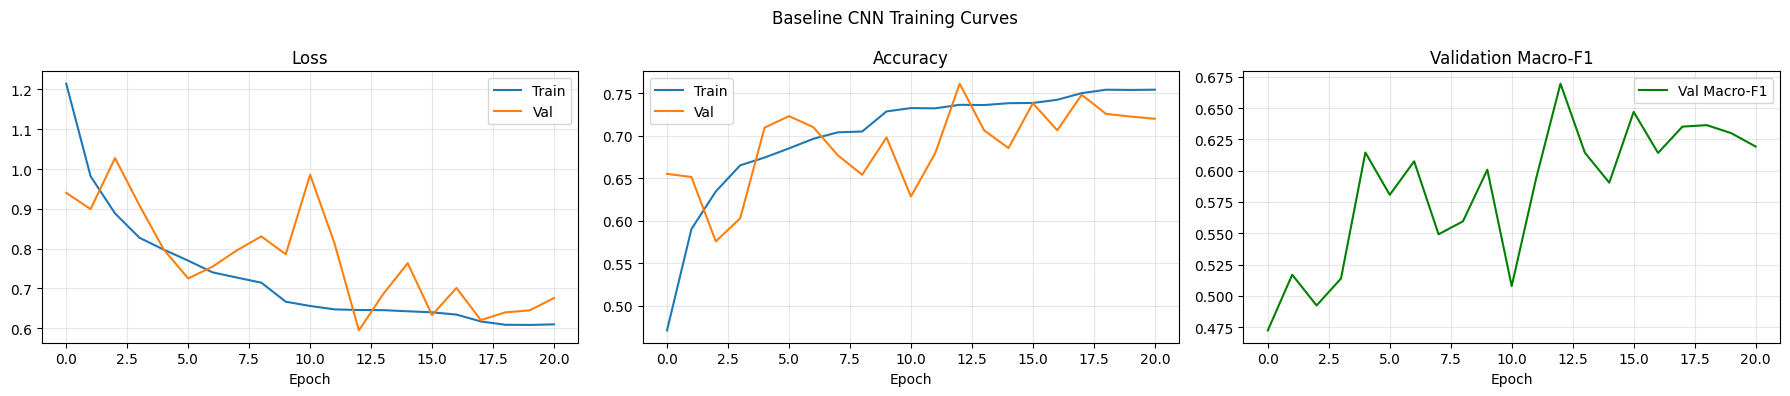


  Baseline CNN — Test Results
Accuracy: 0.7727
Macro F1: 0.6860

              precision    recall  f1-score   support

     Wake(W)     0.9943    0.8337    0.9070       836
          N1     0.3364    0.5106    0.4056       141
          N2     0.8482    0.7233    0.7808       618
          N3     0.5550    0.9308    0.6954       130
         REM     0.5591    0.7513    0.6411       189

    accuracy                         0.7727      1914
   macro avg     0.6586    0.7500    0.6860      1914
weighted avg     0.8258    0.7727    0.7887      1914



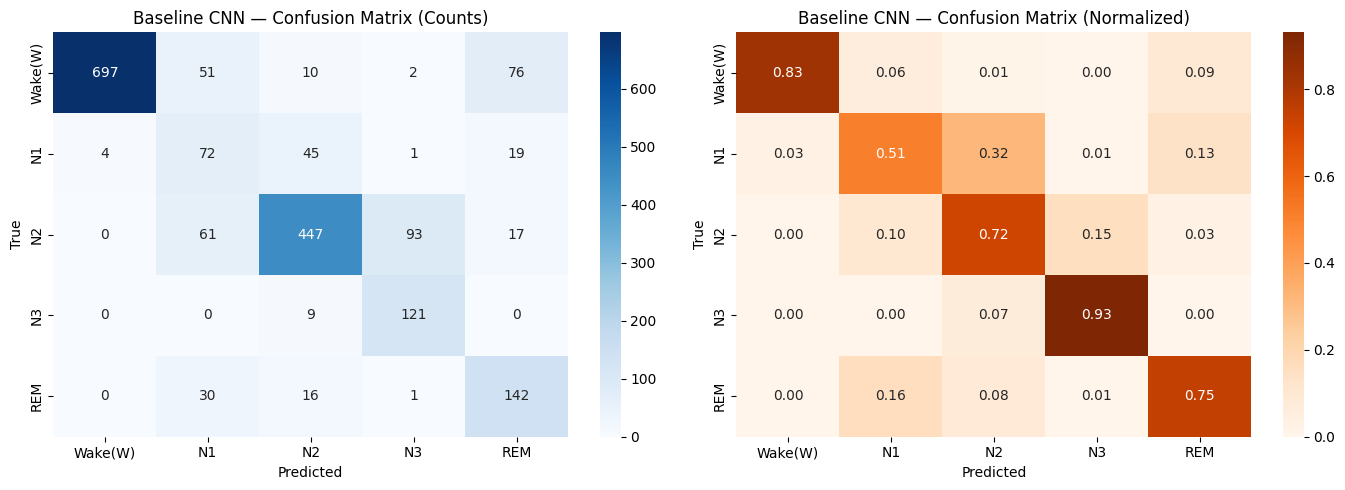


--- Per-Class Analysis ---
Wake(W) : P=0.994 R=0.834 F1=0.907 Support=836
N1      : P=0.336 R=0.511 F1=0.406 Support=141
N2      : P=0.848 R=0.723 F1=0.781 Support=618
N3      : P=0.555 R=0.931 F1=0.695 Support=130
REM     : P=0.559 R=0.751 F1=0.641 Support=189


In [22]:
    print("="*60)
    print("Training BASELINE (CNN)")
    print("="*60)
    baseline = BaselineCNN().to(DEVICE)
    baseline_hist = train_model(baseline, train_loader, val_loader, criterion, "baseline_cnn")
    plot_history(baseline_hist, "Baseline CNN")
    base_acc, base_f1 = full_evaluation(baseline, test_loader, criterion, "Baseline CNN")

  Training MAIN MODEL (CNN-BiLSTM)
Epoch 01/40 | TrLoss: 1.2553 TrAcc: 0.4452 | VaLoss: 0.7929 VaAcc: 0.7132 VaF1: 0.5991
  -> Saved best model (F1=0.5991)
Epoch 02/40 | TrLoss: 0.9943 TrAcc: 0.5835 | VaLoss: 1.0133 VaAcc: 0.5308 VaF1: 0.4125
Epoch 03/40 | TrLoss: 0.8922 TrAcc: 0.6359 | VaLoss: 0.8131 VaAcc: 0.6327 VaF1: 0.5611
Epoch 04/40 | TrLoss: 0.8167 TrAcc: 0.6682 | VaLoss: 0.6869 VaAcc: 0.7351 VaF1: 0.6507
  -> Saved best model (F1=0.6507)
Epoch 05/40 | TrLoss: 0.7650 TrAcc: 0.6925 | VaLoss: 0.7288 VaAcc: 0.7069 VaF1: 0.6300
Epoch 06/40 | TrLoss: 0.7181 TrAcc: 0.7147 | VaLoss: 0.7416 VaAcc: 0.6907 VaF1: 0.6094
Epoch 07/40 | TrLoss: 0.7029 TrAcc: 0.7202 | VaLoss: 0.9167 VaAcc: 0.6630 VaF1: 0.5680
Epoch 08/40 | TrLoss: 0.6728 TrAcc: 0.7305 | VaLoss: 0.6873 VaAcc: 0.7179 VaF1: 0.6315
Epoch 09/40 | TrLoss: 0.5971 TrAcc: 0.7614 | VaLoss: 0.7350 VaAcc: 0.7294 VaF1: 0.6464
Epoch 10/40 | TrLoss: 0.5650 TrAcc: 0.7747 | VaLoss: 0.6763 VaAcc: 0.7419 VaF1: 0.6564
  -> Saved best model (F1=0

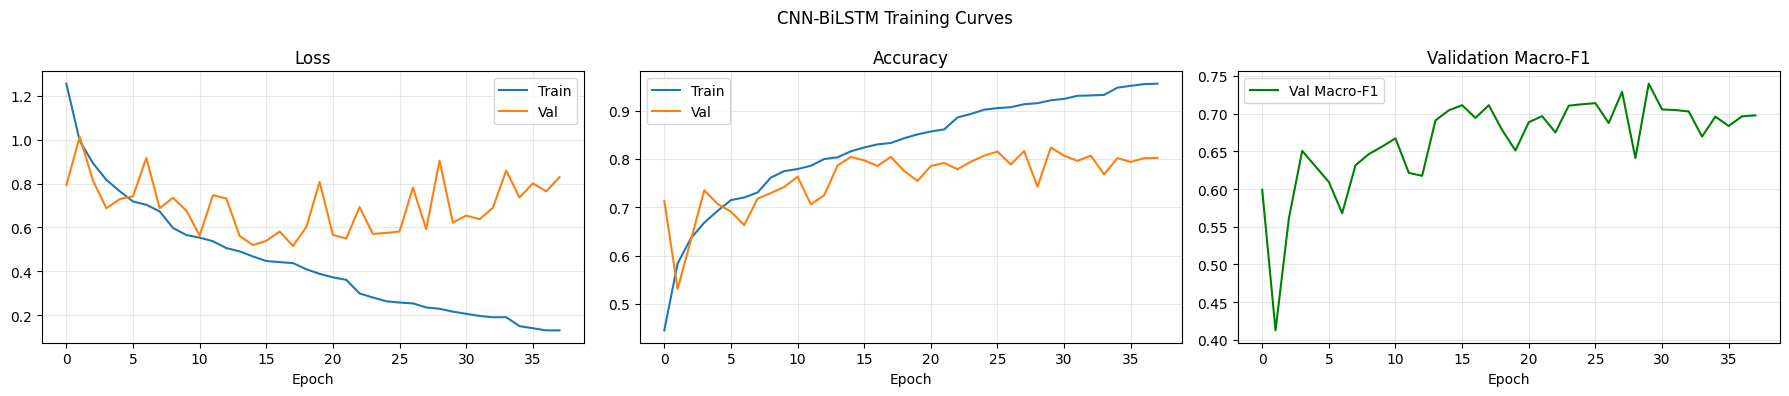


  CNN-BiLSTM — Test Results
Accuracy: 0.8354
Macro F1: 0.7563

              precision    recall  f1-score   support

     Wake(W)     0.9758    0.9163    0.9451       836
          N1     0.3958    0.5390    0.4565       141
          N2     0.8637    0.7896    0.8250       618
          N3     0.7200    0.8308    0.7714       130
         REM     0.7252    0.8519    0.7835       189

    accuracy                         0.8354      1914
   macro avg     0.7361    0.7855    0.7563      1914
weighted avg     0.8548    0.8354    0.8426      1914



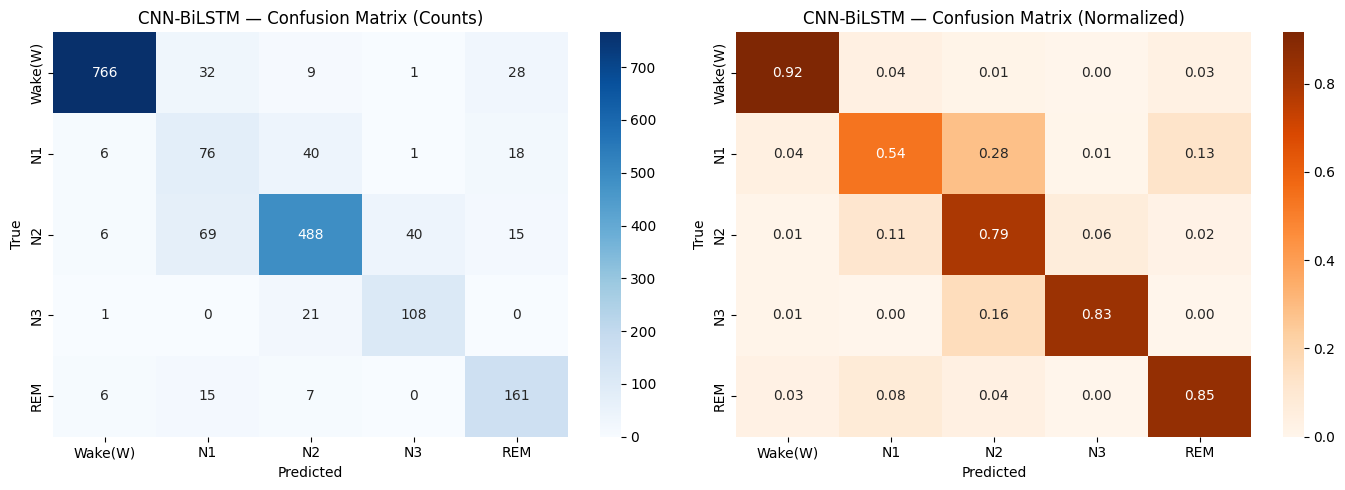


--- Per-Class Analysis ---
Wake(W) : P=0.976 R=0.916 F1=0.945 Support=836
N1      : P=0.396 R=0.539 F1=0.456 Support=141
N2      : P=0.864 R=0.790 F1=0.825 Support=618
N3      : P=0.720 R=0.831 F1=0.771 Support=130
REM     : P=0.725 R=0.852 F1=0.783 Support=189


In [23]:
    print("="*60)
    print("  Training MAIN MODEL (CNN-BiLSTM)")
    print("="*60)
    model = CNN_BiLSTM().to(DEVICE)
    main_hist = train_model(model, train_loader, val_loader, criterion, "cnn_bilstm")
    plot_history(main_hist, "CNN-BiLSTM")
    main_acc, main_f1 = full_evaluation(model, test_loader, criterion, "CNN-BiLSTM")

In [24]:
    print("="*60)
    print("MODEL COMPARISON")
    print("="*60)
    print(f"{'Model':<20} {'Accuracy':<12} {'Macro-F1':<12}")
    print(f"{'-'*44}")
    print(f"{'Baseline CNN':<20} {base_acc:<12.4f} {base_f1:<12.4f}")
    print(f"{'CNN-BiLSTM':<20} {main_acc:<12.4f} {main_f1:<12.4f}")
    improvement = ((main_f1 - base_f1) / base_f1 * 100) if base_f1 > 0 else 0
    print(f"\nCNN-BiLSTM improvement over baseline: {improvement:+.1f}% Macro-F1")

MODEL COMPARISON
Model                Accuracy     Macro-F1    
--------------------------------------------
Baseline CNN         0.7727       0.6860      
CNN-BiLSTM           0.8354       0.7563      

CNN-BiLSTM improvement over baseline: +10.3% Macro-F1
